**AN2DL - First Challenge**

team: marcusai

## 1. Environment Setup
Import shared utilities, fix random seeds, and print environment diagnostics so results remain reproducible across runs.

In [ ]:
# Initialize libraries and reproducibility controls used throughout the notebook
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# Fix random seeds so that shuffling and model initialization remain deterministic
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 2. Data Loading and Initial Diagnostics
Load raw CSV files, merge labels, and quickly inspect any constant or suspicious columns before deeper processing.

- Read `pirate_pain_train.csv` and `pirate_pain_train_labels.csv`
- Merge on `sample_index` and sort by `sample_index, time`
- Scan for constant/zero-variance features (e.g., `joint_30`)

In [ ]:
# Bring feature and label tables into memory and align them by sample_index
train_df  = pd.read_csv("pirate_pain_train.csv")
labels_df = pd.read_csv("pirate_pain_train_labels.csv")

df = train_df.merge(labels_df, on="sample_index", how="inner")

df = df.sort_values(["sample_index", "time"])  # ensure chronological order per sequence

# Quick diagnostic to highlight features with no variance (e.g., joint_30)
for col in df.columns:
    if df[col].nunique() == 1:
        print(col, "has zero variance:", df[col].unique()[0])


joint_30 has zero variance: 0.5


## 3. Feature Selection and Label Encoding
Keep only informative joint coordinates, encode categorical labels, and reshape samples into fixed-length tensors.

- Drop constant `joint_30` if present
- Select only `joint_*` columns as model inputs
- Map labels to deterministic integer IDs and store both directions
- Build `(N, 160, F)` arrays and validate each sample has 160 timesteps

In [ ]:
# Remove constant joints, isolate joint_* columns, and convert labels to integer IDs
if "joint_30" in df.columns:
    df = df.drop(columns=["joint_30"])

feature_cols = [c for c in df.columns if c.startswith("joint_")]
print("Using joint features:", feature_cols)

label_names = sorted(df["label"].unique())
label_to_id = {name: i for i, name in enumerate(label_names)}
id_to_label = {i: name for name, i in label_to_id.items()}
print("Label mapping:", label_to_id)

df["label_id"] = df["label"].map(label_to_id)

X_list, y_list, sample_ids = [], [], []
expected_len = 160  # timesteps per sample

for sid, group in df.groupby("sample_index"):
    features = group[feature_cols].values
    if features.shape[0] != expected_len:
        raise ValueError(f"Sample {sid} has {features.shape[0]} timesteps, expected {expected_len}")
    X_list.append(features)
    y_list.append(group["label_id"].iloc[0])
    sample_ids.append(sid)

X = np.stack(X_list)
y = np.array(y_list)

n_samples, timesteps, num_features = X.shape
num_classes = len(label_names)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("timesteps:", timesteps, "num_features:", num_features, "num_classes:", num_classes)
print("Label distribution (int ids):", Counter(y))
print("Label distribution (names):", {label_names[k]: v for k, v in Counter(y).items()})


Using joint features: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']
Label mapping: {'high_pain': 0, 'low_pain': 1, 'no_pain': 2}
X shape: (661, 160, 30)
y shape: (661,)
timesteps: 160 num_features: 30 num_classes: 3
Label distribution (int ids): Counter({np.int64(2): 511, np.int64(1): 94, np.int64(0): 56})
Label distribution (names): {'no_pain': 511, 'low_pain': 94, 'high_pain': 56}


## 4. Train/Validation Split
Stratify the data to preserve class balance before training and reserve a validation fold for early stopping.

- Perform stratified 80/20 split on labels
- Report shapes of train/validation tensors
- Print per-class counts to verify preserved imbalance profile

In [ ]:
# Hold out a validation fold with class stratification to evaluate configs fairly
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)
print("Original train distribution:", Counter(y_train))
print("Validation distribution:", Counter(y_val))


Train shape: (528, 160, 30) Val shape: (133, 160, 30)
Original train distribution: Counter({np.int64(2): 408, np.int64(1): 75, np.int64(0): 45})
Validation distribution: Counter({np.int64(2): 103, np.int64(1): 19, np.int64(0): 11})


## 5. Training Utilities
Define reusable callbacks and oversampling helpers that will be shared by every experimental run.

- `F1Callback`: computes and logs validation macro-F1 each epoch
- `oversample_sequences`: balances classes to majority count (train only)
- Shuffle after oversampling and print before/after class counts

In [ ]:
# Callback reports macro F1 each epoch and mirrors it into logs for early stopping
class F1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X_val, verbose=0)
        y_pred_labels = np.argmax(y_pred, axis=1)
        f1 = f1_score(self.y_val, y_pred_labels, average="macro")
        if logs is not None:
            logs["val_f1_macro"] = f1
        print(f" — val_f1_macro: {f1:.4f}")

# Oversample each class to the frequency of the majority class to fight imbalance
def oversample_sequences(X_train, y_train):
    """Return class-balanced copies of X_train and y_train via random oversampling."""
    classes, counts = np.unique(y_train, return_counts=True)
    print("Before oversampling:", dict(zip(classes, counts)))

    max_count = np.max(counts)
    X_resampled_list, y_resampled_list = [], []

    for c in classes:
        X_c = X_train[y_train == c]
        y_c = y_train[y_train == c]

        if len(X_c) == max_count:
            X_c_resampled, y_c_resampled = X_c, y_c
        else:
            X_c_resampled, y_c_resampled = resample(
                X_c, y_c,
                replace=True,
                n_samples=max_count,
                random_state=42
            )

        X_resampled_list.append(X_c_resampled)
        y_resampled_list.append(y_c_resampled)

    X_resampled = np.concatenate(X_resampled_list, axis=0)
    y_resampled = np.concatenate(y_resampled_list, axis=0)

    idx = np.arange(len(y_resampled))
    np.random.shuffle(idx)
    X_resampled = X_resampled[idx]
    y_resampled = y_resampled[idx]

    classes_res, counts_res = np.unique(y_resampled, return_counts=True)
    print("After oversampling:", dict(zip(classes_res, counts_res)))

    return X_resampled, y_resampled


## 6. Model Definition
Construct the BiLSTM + Multi-Head Attention backbone that serves every experiment.

- Two BiLSTM layers (128, 64) with LayerNorm and Dropout
- Multi-Head Attention with residual connection
- GlobalAveragePooling1D and Swish dense head (256 → 128)
- Compile with Adam and Sparse CCE; report a model summary

In [ ]:
# Define BiLSTM + Multi-Head Attention classifier with Swish dense head
def build_bilstm_mha_model(timesteps, num_features, num_classes, learning_rate=7e-4):
    inputs = layers.Input(shape=(timesteps, num_features))

    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, activation="tanh")
    )(inputs)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, activation="tanh")
    )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)

    attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(256, activation="swish")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="swish")(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="BiLSTM_MHA_Swish")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()
    return model


## 7. Hyperparameter Search
Enumerate candidate training regimes and iterate through them while tracking macro F1.

- Define a small grid over learning rate and batch size
- Train each config with oversampling (train only) and early stopping on macro-F1
- Record validation macro-F1 and keep the best-performing model

In [ ]:
# Candidate configurations spanning learning rate, batch size, and oversampling usage
configs = [
    {"name": "lr1e-3_bs32_osTrue",  "learning_rate": 1e-3, "batch_size": 32, "use_oversampling": True},
    {"name": "lr7e-4_bs32_osTrue",  "learning_rate": 7e-4, "batch_size": 32, "use_oversampling": True},
    {"name": "lr5e-4_bs32_osTrue",  "learning_rate": 5e-4, "batch_size": 32, "use_oversampling": True},
    {"name": "lr1e-3_bs16_osTrue",  "learning_rate": 1e-3, "batch_size": 16, "use_oversampling": True},
    {"name": "lr7e-4_bs16_osTrue",  "learning_rate": 7e-4, "batch_size": 16, "use_oversampling": True},
    {"name": "lr5e-4_bs16_osTrue",  "learning_rate": 5e-4, "batch_size": 16, "use_oversampling": True},
]

print("Configs to try:")
for c in configs:
    print(" -", c["name"])


Configs to try:
 - lr1e-3_bs32_osTrue
 - lr7e-4_bs32_osTrue
 - lr5e-4_bs32_osTrue
 - lr1e-3_bs16_osTrue
 - lr7e-4_bs16_osTrue
 - lr5e-4_bs16_osTrue


In [ ]:
# Iterate through every configuration, train, and log validation macro F1
results = {}
best_config = None
best_f1 = -1.0
best_model = None

print(f"Starting hyperparameter search over {len(configs)} configs\n")

for cfg in configs:
    print("\n==============================")
    print("Config:", cfg["name"])
    print("==============================")

    if cfg["use_oversampling"]:
        X_train_in, y_train_in = oversample_sequences(X_train, y_train)
    else:
        X_train_in, y_train_in = X_train, y_train
        print("Using original (not oversampled) training data.")

    print("Train shape:", X_train_in.shape, "Val shape:", X_val.shape)

    model = build_bilstm_mha_model(
        timesteps=timesteps,
        num_features=num_features,
        num_classes=num_classes,
        learning_rate=cfg["learning_rate"]
    )

    f1_cb = F1Callback(X_val, y_val)
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        X_train_in, y_train_in,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=cfg["batch_size"],
        shuffle=True,
        callbacks=[f1_cb, early_stopping],
        verbose=1
    )

    y_val_pred_proba = model.predict(X_val, verbose=0)
    y_val_pred = np.argmax(y_val_pred_proba, axis=1)
    f1_macro = f1_score(y_val, y_val_pred, average="macro")

    results[cfg["name"]] = {
        "f1_macro": f1_macro,
    }

    print(f"\nConfig {cfg['name']} F1-macro on validation: {f1_macro:.4f}")

    if f1_macro > best_f1:
        best_f1 = f1_macro
        best_config = cfg
        best_model = model

print("\n=======================================")
print("Best config:", best_config["name"])
print(f"Best F1-macro on validation: {best_f1:.4f}")
print("=======================================")

print("\nAll config results:")
for name, res in results.items():
    print(f"{name}: F1-macro = {res['f1_macro']:.4f}")


Starting hyperparameter search over 6 configs


Config: lr1e-3_bs32_osTrue
Before oversampling: {np.int64(0): np.int64(45), np.int64(1): np.int64(75), np.int64(2): np.int64(408)}
After oversampling: {np.int64(0): np.int64(408), np.int64(1): np.int64(408), np.int64(2): np.int64(408)}
Train shape: (1224, 160, 30) Val shape: (133, 160, 30)


Model: "BiLSTM_MHA_Swish"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 160, 30)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 160, 256)  │    162,816 │ input_layer_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 256)  │        512 │ bidirectional_4[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 160, 256)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 160, 128)  │    164,352 │ dropout_8[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 128)  │        256 │ bidirectional_5[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 160, 128)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 160, 128)  │    131,968 │ dropout_9[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 160, 128)  │          0 │ dropout_9[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256)       │          0 │ dense_6[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 3)         │        387 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 526,467 (2.01 MB)

 Trainable params: 526,467 (2.01 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 160, 30)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_14    │ (None, 160, 256)  │    162,816 │ input_layer_7[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 256)  │        512 │ bidirectional_14… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 160, 256)  │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_15    │ (None, 160, 128)  │    164,352 │ dropout_28[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 128)  │        256 │ bidirectional_15… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 160, 128)  │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 160, 128)  │    131,968 │ dropout_29[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 160, 128)  │          0 │ dropout_29[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 128)  │        256 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 256)       │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │     32,896 │ dropout_31[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 3)         │        387 │ dense_22[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 526,467 (2.01 MB)

 Trainable params: 526,467 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.3984 - loss: 1.0955 — val_f1_macro: 0.5925
77/77 ━━━━━━━━━━━━━━━━━━━━ 54s 581ms/step - accuracy: 0.3991 - loss: 1.0946 - val_accuracy: 0.7143 - val_loss: 0.6432 - val_f1_macro: 0.5925
Epoch 2/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.6283 - loss: 0.7941 — val_f1_macro: 0.6749
77/77 ━━━━━━━━━━━━━━━━━━━━ 41s 531ms/step - accuracy: 0.6288 - loss: 0.7935 - val_accuracy: 0.8346 - val_loss: 0.5024 - val_f1_macro: 0.6749
Epoch 3/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.7212 - loss: 0.6240 — val_f1_macro: 0.7073
77/77 ━━━━━━━━━━━━━━━━━━━━ 41s 533ms/step - accuracy: 0.7212 - loss: 0.6238 - val_accuracy: 0.8647 - val_loss: 0.3596 - val_f1_macro: 0.7073
Epoch 4/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.7937 - loss: 0.5056 — val_f1_macro: 0.6412
77/77 ━━━━━━━━━━━━━━━━━━━━ 41s 534ms/step - accuracy: 0.7938 - loss: 0.5052 - val_accuracy: 0.8496 - val_loss: 0.5849 - val_f1_macro: 0.6412


## 8. Best-Model Evaluation and Persistence
Inspect the winning configuration, compute detailed metrics, and serialize weights for later use.

- Compute macro/micro/weighted F1 on validation set
- Print full classification report and confusion matrix
- Save the best-performing model to `pirate_pain_model.keras`

In [ ]:
# Summarize performance of the best configuration on the validation split
final_model = best_model

y_val_pred_proba = final_model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

print("\nFinal model validation metrics (best config):")
print("F1 macro   :", f1_score(y_val, y_val_pred, average="macro"))
print("F1 micro   :", f1_score(y_val, y_val_pred, average="micro"))
print("F1 weighted:", f1_score(y_val, y_val_pred, average="weighted"))

print("\nClassification report:")
print(classification_report(y_val, y_val_pred, target_names=label_names))

print("Confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))



Final model validation metrics (best config):
F1 macro   : 0.8553329240386226
F1 micro   : 0.9398496240601504
F1 weighted: 0.9409020961736261

Classification report:
              precision    recall  f1-score   support

   high_pain       0.67      0.73      0.70        11
    low_pain       0.89      0.89      0.89        19
     no_pain       0.98      0.97      0.98       103

    accuracy                           0.94       133
   macro avg       0.85      0.86      0.86       133
weighted avg       0.94      0.94      0.94       133

Confusion matrix:
[[  8   1   2]
 [  2  17   0]
 [  2   1 100]]


In [ ]:
# Persist current best model for reproducibility
final_model.save('pirate_pain_model.keras')
print("Model saved to pirate_pain_model.keras")

Model saved to pirate_pain_model.keras


## 9. Submission Pipeline (Validation-Trained Model)
Reload the saved checkpoint and produce predictions for the public leaderboard using identical preprocessing.


In [ ]:
# Reload checkpoint, preprocess test set identically, and export submission
model = tf.keras.models.load_model("pirate_pain_model.keras")
print("Model loaded.")

# Load test dataset and drop constant columns
test_df = pd.read_csv("pirate_pain_test.csv")
if "joint_30" in test_df.columns:
    test_df = test_df.drop(columns=["joint_30"])

feature_cols = [c for c in test_df.columns if c.startswith("joint_")]

test_df = test_df.sort_values(["sample_index", "time"])

expected_len = 160
X_test_list = []
test_sample_ids = []

for sid, group in test_df.groupby("sample_index"):
    arr = group[feature_cols].values
    if arr.shape[0] != expected_len:
        raise ValueError(f"Sample {sid} has {arr.shape[0]} timesteps, expected {expected_len}.")
    X_test_list.append(arr)
    test_sample_ids.append(sid)

X_test = np.stack(X_test_list)
print("X_test shape:", X_test.shape)

proba = model.predict(X_test)
pred_ids = np.argmax(proba, axis=1)

label_names = ['high_pain', 'low_pain', 'no_pain']
label_to_id = {name: i for i, name in enumerate(label_names)}
id_to_label = {v: k for k, v in label_to_id.items()}

pred_labels = [id_to_label[i] for i in pred_ids]

submission = pd.DataFrame({
    "sample_index": test_sample_ids,
    "label": pred_labels
})

submission.head()
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Model loaded.
X_test shape: (1324, 160, 30)
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 371ms/step
Saved submission.csv


## 10. Full-Data Training and Final Submission
Retrain the model on the entire labeled set (after oversampling) and regenerate predictions for the final upload.

- Oversample the full training set to balance classes
- Retrain with best hyperparameters on all labeled data
- Save final weights to `pirate_pain_model_final.keras` and regenerate submission

In [ ]:
# Oversample the full dataset, retrain with best hyperparameters, and save final weights
print("Original full data shape:", X.shape, y.shape)

X_full_os, y_full_os = oversample_sequences(X, y)
print("Oversampled full data shape:", X_full_os.shape, y_full_os.shape)

best_learning_rate = 1e-3
best_batch_size = 32

final_model_full = build_bilstm_mha_model(
    timesteps=timesteps,
    num_features=num_features,
    num_classes=num_classes,
    learning_rate=best_learning_rate
)

history_full = final_model_full.fit(
    X_full_os, y_full_os,
    epochs=20,
    batch_size=best_batch_size,
    shuffle=True,
    verbose=1
)

final_model_full.save("pirate_pain_model_final.keras")
print("Final model trained on ALL labeled data and saved to pirate_pain_model_final.keras")


Original full data shape: (661, 160, 30) (661,)
Before oversampling: {np.int64(0): np.int64(56), np.int64(1): np.int64(94), np.int64(2): np.int64(511)}
After oversampling: {np.int64(0): np.int64(511), np.int64(1): np.int64(511), np.int64(2): np.int64(511)}
Oversampled full data shape: (1533, 160, 30) (1533,)


Model: "BiLSTM_MHA_Swish"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 30)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 160, 256)  │    162,816 │ input_layer_1[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 256)  │        512 │ bidirectional_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 160, 256)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 160, 128)  │    164,352 │ dropout_8[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 128)  │        256 │ bidirectional_3[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 160, 128)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 160, 128)  │    131,968 │ dropout_9[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 160, 128)  │          0 │ dropout_9[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256)       │          0 │ dense_3[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        387 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 526,467 (2.01 MB)

 Trainable params: 526,467 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3886 - loss: 1.1461
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.4886 - loss: 0.9840
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6939 - loss: 0.7266
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6999 - loss: 0.6807
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7667 - loss: 0.5613
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8155 - loss: 0.4454
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8048 - loss: 0.5078
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8560 - loss: 0.3567
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8969 - loss: 0.2647
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8995 - loss: 0.2617
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9302 - loss: 0.1814
Epoch 12/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8970 - lo

In [ ]:
# Use the full-data model to create the final competition submission
model = tf.keras.models.load_model("pirate_pain_model_final.keras")
print("Model loaded.")

test_df = pd.read_csv("pirate_pain_test.csv")
if "joint_30" in test_df.columns:
    test_df = test_df.drop(columns=["joint_30"])

feature_cols = [c for c in test_df.columns if c.startswith("joint_")]

test_df = test_df.sort_values(["sample_index", "time"])

expected_len = 160
X_test_list = []
test_sample_ids = []

for sid, group in test_df.groupby("sample_index"):
    arr = group[feature_cols].values
    if arr.shape[0] != expected_len:
        raise ValueError(f"Sample {sid} has {arr.shape[0]} timesteps, expected {expected_len}.")
    X_test_list.append(arr)
    test_sample_ids.append(sid)

X_test = np.stack(X_test_list)
print("X_test shape:", X_test.shape)

proba = model.predict(X_test)
pred_ids = np.argmax(proba, axis=1)

label_names = ['high_pain', 'low_pain', 'no_pain']
label_to_id = {name: i for i, name in enumerate(label_names)}
id_to_label = {v: k for k, v in label_to_id.items()}

pred_labels = [id_to_label[i] for i in pred_ids]

submission = pd.DataFrame({
    "sample_index": test_sample_ids,
    "label": pred_labels
})

submission.head()
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Model loaded.
X_test shape: (1324, 160, 30)
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 343ms/step
Saved submission.csv


## 11. Training Log Visualization
Parse the saved training log to visualize loss, accuracy, and macro F1 curves for quick diagnostics.

- Parse `log.txt` to extract training/validation metrics per epoch
- Plot loss and accuracy curves to assess convergence
- Plot validation macro-F1 to verify early stopping behavior

Parsed 52 epochs


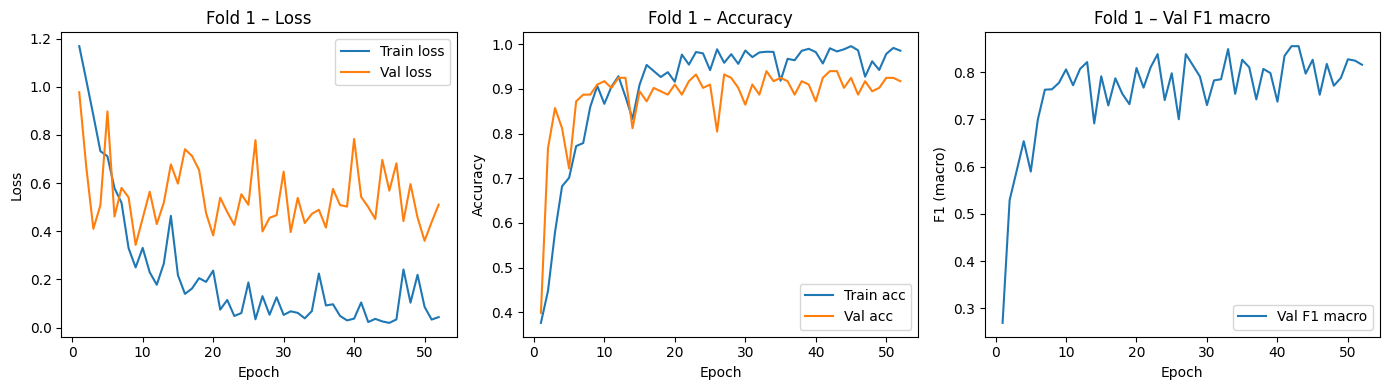

In [ ]:
# Parse the console log file and plot training vs. validation traces for diagnostics
import re
import matplotlib.pyplot as plt

log_path = "log.txt"  # captured stdout from training above

train_loss, val_loss = [], []
train_acc, val_acc = [], []
val_f1 = []

with open(log_path, "r", encoding="utf-8") as f:
    for line in f:
        if "val_accuracy" in line and "val_f1_macro" in line:
            m = re.search(
                r"accuracy:\s*([0-9.]+)\s*-\s*loss:\s*([0-9.]+).*?"
                r"val_accuracy:\s*([0-9.]+)\s*-\s*val_loss:\s*([0-9.]+).*?"
                r"val_f1_macro:\s*([0-9.]+)",
                line
            )
            if m:
                tr_acc, tr_loss, va_acc, va_loss, f1 = map(float, m.groups())
                train_acc.append(tr_acc)
                train_loss.append(tr_loss)
                val_acc.append(va_acc)
                val_loss.append(va_loss)
                val_f1.append(f1)

print(f"Parsed {len(train_loss)} epochs")

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fold 1 – Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, train_acc, label="Train acc")
plt.plot(epochs, val_acc, label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fold 1 – Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, val_f1, label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 (macro)")
plt.title("Fold 1 – Val F1 macro")
plt.legend()

plt.tight_layout()
plt.show()
